In [126]:
%load_ext autoreload
%autoreload 2
# general
import os
import sys
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# settings
# repo_dir = '/home/labs/amit/annaku/repos/MM_2023'
# sys.path.append(repo_dir)
pd.set_option('display.max_columns', 200)
# specific
# from omegaconf import OmegaConf
import anndata as ad
# my
from plotting.utils import generate_color_palette
from plotting.palettes import *
from survival.km import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
#example data

data_path = '/home/labs/amit/annaku/repos/MM_2024_AK/data/'
version = '20240813'

ann = pd.read_csv(os.path.join(data_path, f'ann_patient_level_v_{version}.csv'), index_col=0)

In [128]:
print(ann.shape)

(219, 183)


In [129]:
ann_km = ann.copy()
ann_km =ann_km[ann_km['pc_annotation'] == 'Malignant']

# important: rename these columns

ann_km = ann_km.rename(columns = {' PFS (Months)': 'PFS',
                                  'PFS Event':'PFS_event',
                                  'OS (Months)':'OS',
                                  'Death Event':'OS_event'})

# KM between labels

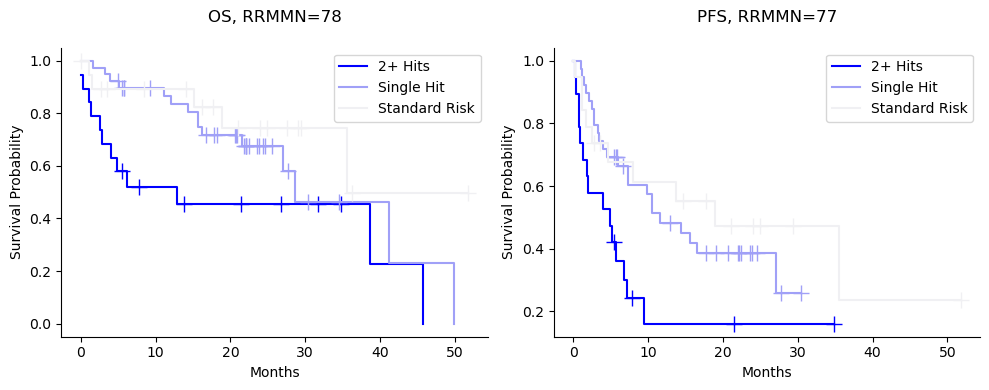

In [130]:
mask = ann_km['Disease'] == 'RRMM'

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

survivals_os = create_survival_annotation(
    ann_km[mask]["OS"].replace({"NA": None}),
    ann_km["OS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

survivals_pfs = create_survival_annotation(
    ann_km[mask]["PFS"].replace({"NA": None}),
    ann_km["PFS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

for ax, survival, title_suffix in zip(axes, [survivals_os, survivals_pfs], ['OS', 'PFS']):

    plot_kaplan_meier(ann_km[mask]['Cyto_Risk'].dropna().astype(str), survival,
                        palette=pal_cytorisk,
                        show_pvalue=True,
                        title_n_samples=True,
                        title=f'{title_suffix}' + ', RRMM',
                        add_at_risk=False,
                        legend='in',
                        ax=ax)
    ax.set_xlabel('Months')
    ax.set_ylabel('Survival Probability')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.get_legend().remove() 

plt.tight_layout()
# plt.savefig(f'{save_dir}/name.svg', format='svg')
# plt.savefig(f'{save_dir}/name.png', format='png')
plt.show()

In [131]:
ann_km['1q21+'].value_counts()

1q21+
No     56
Yes    55
Name: count, dtype: int64

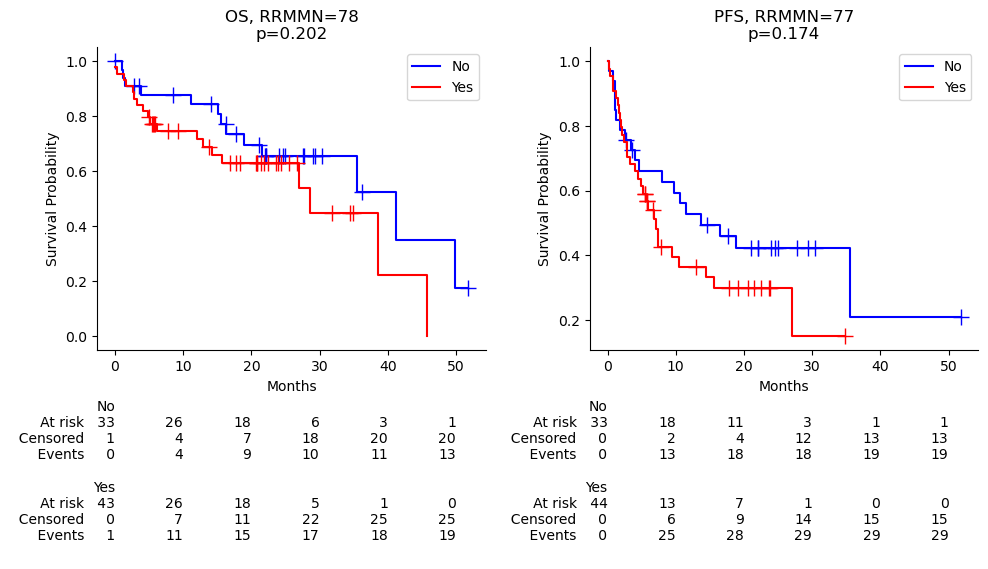

In [132]:
mask = ann_km['Disease'] == 'RRMM'

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

survivals_os = create_survival_annotation(
    ann_km[mask]["OS"].replace({"NA": None}),
    ann_km["OS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

survivals_pfs = create_survival_annotation(
    ann_km[mask]["PFS"].replace({"NA": None}),
    ann_km["PFS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

for ax, survival, title_suffix in zip(axes, [survivals_os, survivals_pfs], ['OS', 'PFS']):

    plot_kaplan_meier(ann_km[mask]['1q21+'].dropna().astype(str), survival,
                        palette={'Yes':'red', 'No':'blue'},
                        show_pvalue=True,
                        title_n_samples=True,
                        title=f'{title_suffix}' + ', RRMM',
                        add_at_risk=True,
                        #legend='in',
                        ax=ax)
    ax.set_xlabel('Months')
    ax.set_ylabel('Survival Probability')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.get_legend().remove() 

plt.tight_layout()
# plt.savefig(f'{save_dir}/name.svg', format='svg')
# plt.savefig(f'{save_dir}/name.png', format='png')
plt.show()

# KM between quantilies

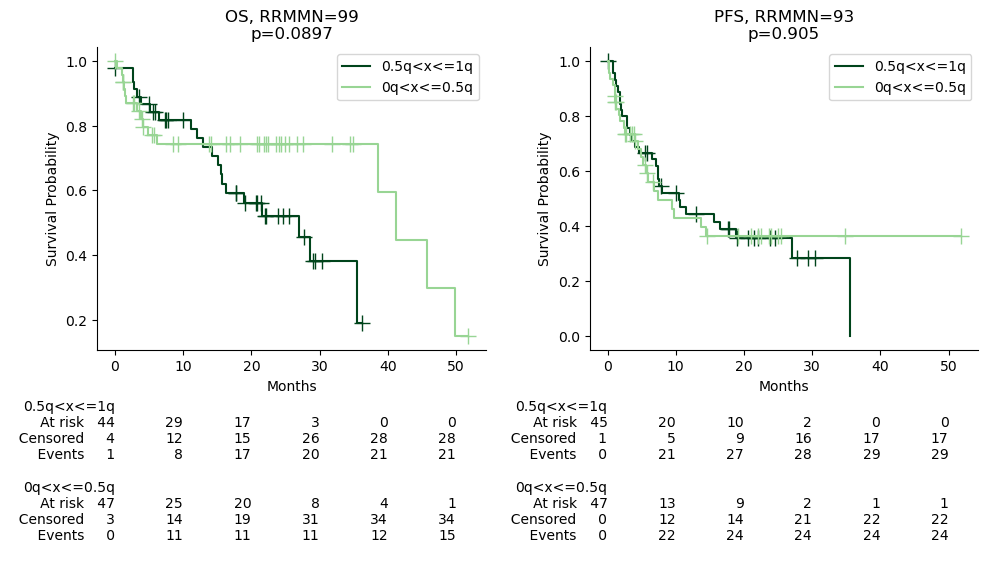

In [133]:
mask = ann_km['Disease'] == 'RRMM'

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

survivals_os = create_survival_annotation(
    ann_km[mask]["OS"].replace({"NA": None}),
    ann_km["OS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

survivals_pfs = create_survival_annotation(
    ann_km[mask]["PFS"].replace({"NA": None}),
    ann_km["PFS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

for ax, survival, title_suffix in zip(axes, [survivals_os, survivals_pfs], ['OS', 'PFS']):

    plot_kaplan_meier_quantiles(ann_km['Total.PC'], survival,
                        q=[.5],
                        show_pvalue=True,
                        title_n_samples=True,
                        title=f'{title_suffix}' + ', RRMM',
                        add_at_risk=True,
                        ax=ax)
    ax.set_xlabel('Months')
    ax.set_ylabel('Survival Probability')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    #ax.get_legend().remove() 

plt.tight_layout()
# plt.savefig(f'{save_dir}/name.svg', format='svg')
# plt.savefig(f'{save_dir}/name.png', format='png')
plt.show()

In [134]:
# calculate logrank test between given quantiles. Only for 2 groups

## assumptions! tocheck. Do pval adj if needed

mask = ann_km['Disease'] == 'RRMM'

survivals_os = create_survival_annotation(
    ann_km[mask]["OS"].replace({"NA": None}),
    ann_km["OS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

survivals_pfs = create_survival_annotation(
    ann_km[mask]["PFS"].replace({"NA": None}),
    ann_km["PFS_event"].replace({"NA": None}),
    in_units='Months',
out_units='Months',
)

N, pval = logrank_on_quantiles(ann_km[mask]['Total.PC'], survival,q=[.5],)
N, pval

(93, 0.9048932893031648)

In [135]:
# pvals = results_df['pval'].values
# reject, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method='fdr_bh')